In [1]:
import numpy as np
from matplotlib import pyplot as plt
from Bagging_for_LID.RunningEstimators.BaseEstimators import *
from Bagging_for_LID.run_files.final_tasks import *
from Bagging_for_LID.experiment_class import *
from Bagging_for_LID.RunningEstimators.Running2 import *
from Bagging_for_LID.Plotting.Plots.VariableInteraction import *
from Bagging_for_LID.Plotting.Plots.distance_LID import *
import skdim

In [2]:
ratio = 0.01
data, lids = ribbon_multi_dim_equal_density(2500, dim=2, d_loc=2, d_glob=1, ratio=ratio)

In [3]:
def plot_data(data):
    plt.figure(figsize=(6, 6))
    plt.scatter(data[:,0], data[:,1], s=1) #, marker='.', edgecolors='none', linewidths=0, antialiased=False
    plt.xlim(0, 1)
    plt.ylim(-1.5*ratio, 2.5*ratio)
    #plt.ylim(0, ratio)
    plt.savefig('ribbon.pdf')
    plt.show()

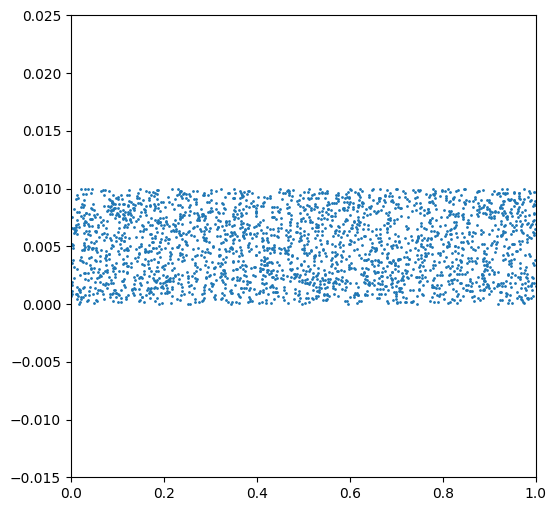

In [4]:
plot_data(data)

In [5]:
k_geomprog_large = geom_prog(min=5, max=200, step=50, integer=True, remove_duplicates=True)

In [6]:
trange = [t for t in range(50)]

In [7]:
def generate_all_experiments(krange, trange, load=False):
    all_experiments = []
    
    for t in trange:
        
        param_dicts_data = {'dataset_name': 'ribbon',
               'n': 2500,
               'lid': None,
               'dim': None,
               'estimator_name': 'mle',
               'bagging_method': None,
               'submethod_0': '0',
               'submethod_error': 'log_diff',
               'k': 10,
               'sr': 1,
               'Nbag': 10,
               'pre_smooth': False,
               'post_smooth': False,
               't': 1}
        
        param_dicts = {'dataset_name': 'ribbon',
               'n': 2500,
               'lid': None,
               'dim': None,
               'estimator_name': 'mle',
               'bagging_method': None,
               'submethod_0': '0',
               'submethod_error': 'log_diff',
               'k': krange,
               'sr': 1,
               'Nbag': 10,
               'pre_smooth': False,
               'post_smooth': False,
               't': t}
        
        fixpoints = [np.array([[0.5, 0.005]]), np.array([2]), None, np.array([2])]
        
        results_data = new_result_generator(param_dicts_data, multiprocess=False, load=load, load_data=load,
                                            worker_count=None,
                                            save_name='data_generation_ribbon',
                                            directory=r'C:\Users\krp\PycharmProjects\FinalFixLIDGit\pkls', fixpoints=fixpoints)
        
        experiments = new_lid_and_knn_dist_result_generator(param_dicts, multiprocess=True, load=load, load_data=True, worker_count=5, save_name=f'ribbon_test_example_t_{t}', directory=r'C:\Users\krp\PycharmProjects\FinalFixLIDGit\pkls')
        all_experiments = all_experiments + experiments
        
    return all_experiments

In [8]:
def avg_experiments_using_t_as_index(experiments, trange, krange):
    experiments_t_k = {(t, k): None for t in trange for k in krange}
    for experiment in experiments:
        experiments_t_k[(experiment.t, experiment.k)] = experiment
    experiments_0_k_with_avg_estimates = {k: experiments_t_k[(0, k)] for k in krange}
    experiments_avg_lid_estimates = {k: np.mean([experiments_t_k[(t, k)].lid_estimates for t in trange], axis=0) for k in krange}
    experiments_std_lid_estimates = {k: np.std([experiments_t_k[(t, k)].lid_estimates for t in trange], axis=0) for k in krange}
    for k in krange:
        experiments_0_k_with_avg_estimates[k].lid_estimates = experiments_avg_lid_estimates[k]
        experiments_0_k_with_avg_estimates[k].lid_estimates_std = experiments_std_lid_estimates[k]
    exps = [experiments_0_k_with_avg_estimates[k] for k in k_geomprog_large]
    return exps, experiments_0_k_with_avg_estimates, experiments_t_k

In [9]:
experiments = generate_all_experiments(k_geomprog_large, trange, load=True)

<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\data_generation_ribbon'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\ribbon_test_example_t_0'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\data_generation_ribbon'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\ribbon_test_example_t_1'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\data_generation_ribbon'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\ribbon_test_example_t_2'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\data_generation_ribbon'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\ribbon_test_example_t_3'>
<_io.BufferedReader name='C:\\Users\\krp\\PycharmProjects\\FinalFixLIDGit\\pkls\\data_generation_ribbon'>
<_io.BufferedReader name='C:\\Users\\krp\\

In [10]:
exps, experiments_0_k_with_avg_estimates, experiments_t_k = avg_experiments_using_t_as_index(experiments, trange, k_geomprog_large)

In [11]:
exps = [experiments_0_k_with_avg_estimates[k] for k in k_geomprog_large[0:len(k_geomprog_large)-8]]

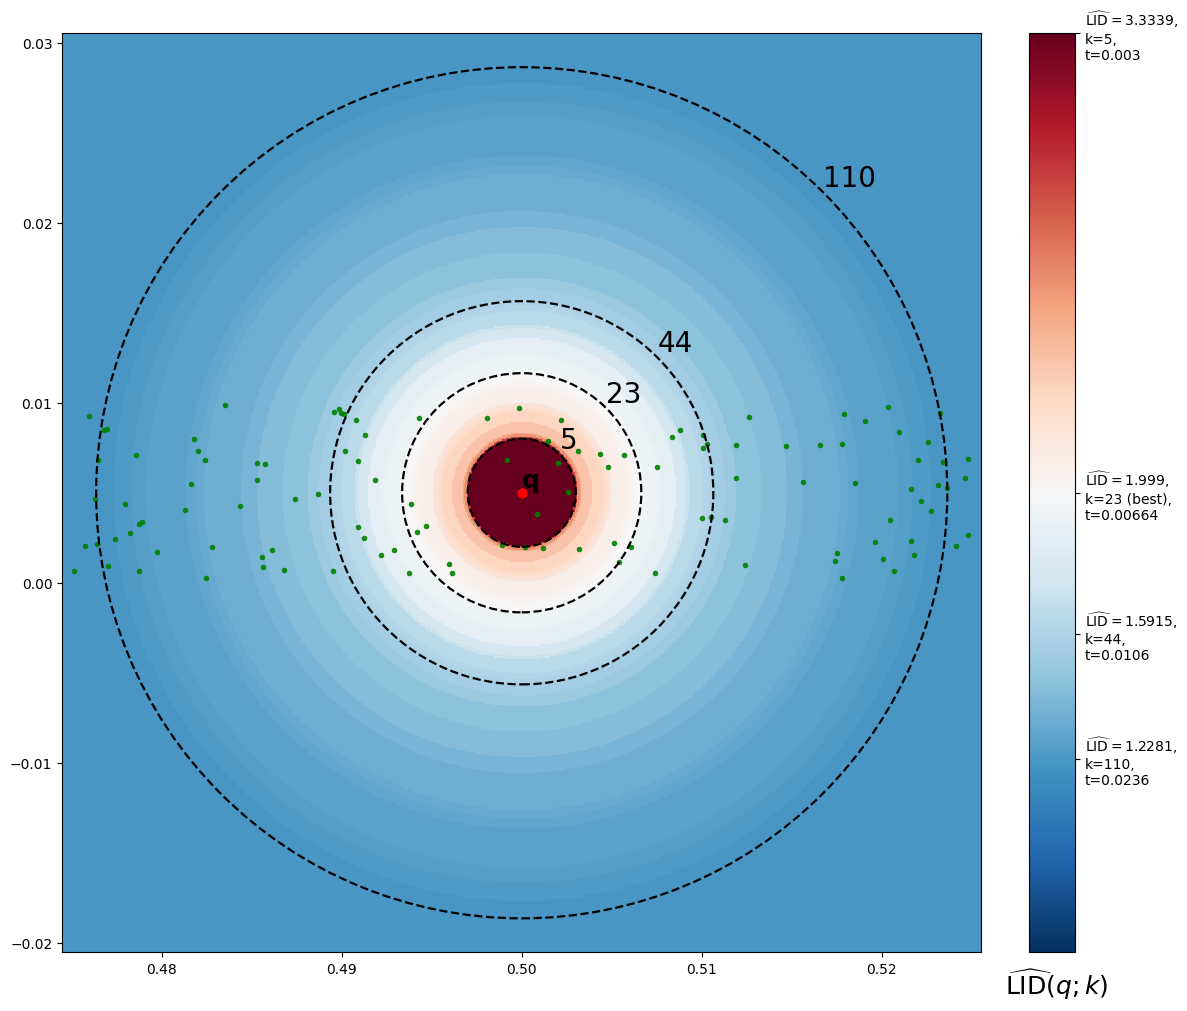

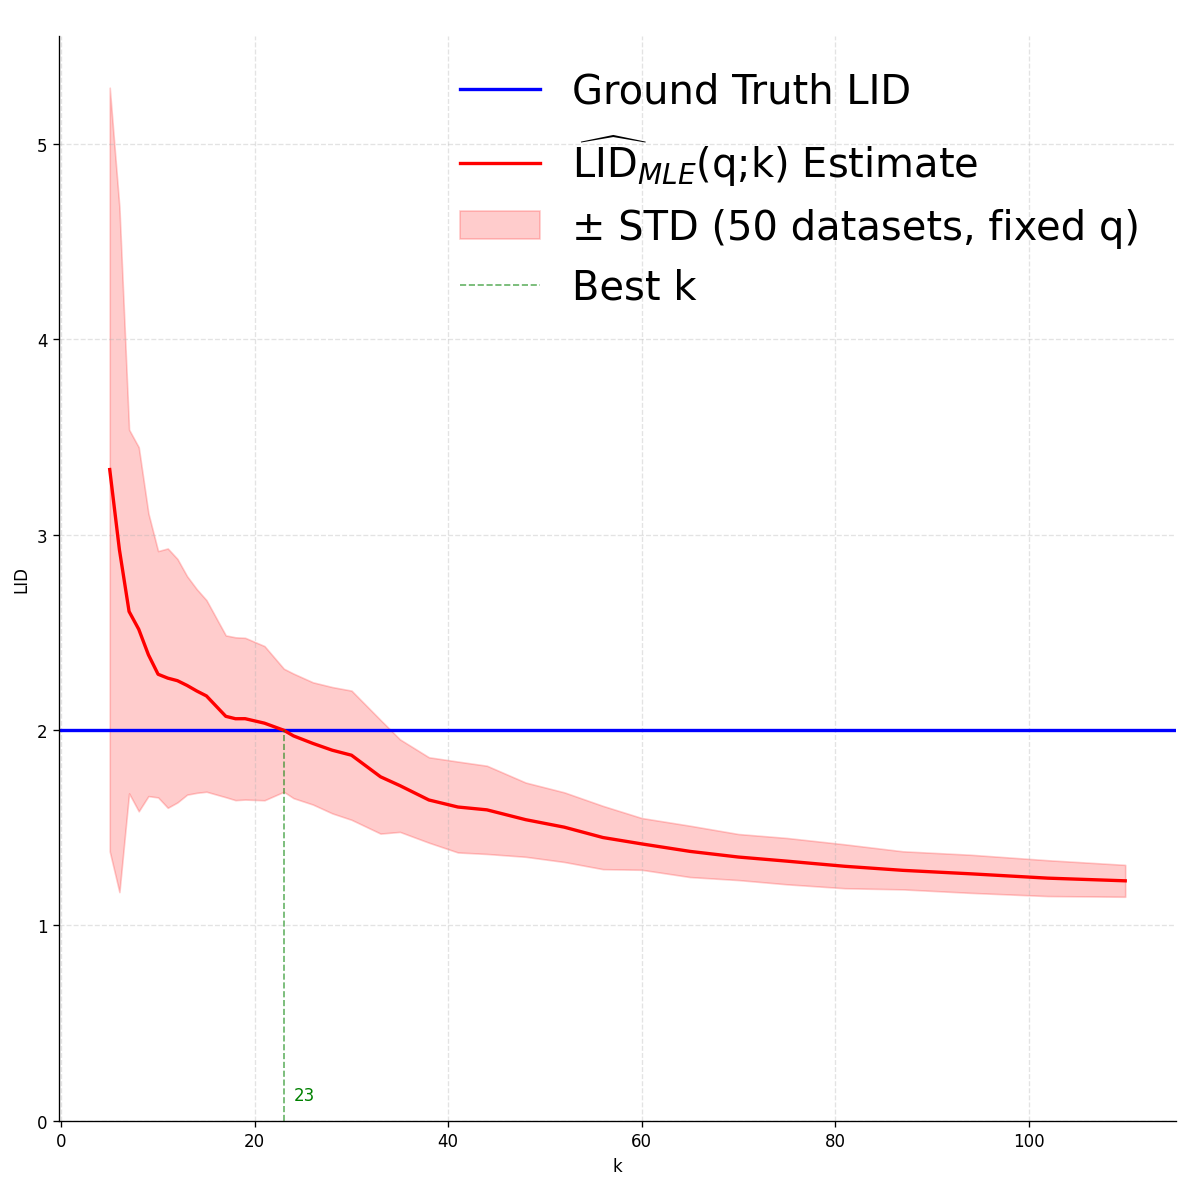

In [12]:
# choose the query point index
i = 2500

fig, ax, im, (ks, radii, vals, gt, best_k) = plot_point_knn_rings_lid_field(
    exps,
    i=i,
    extent_mode="knn_radius",
    cmap_name="RdBu_r",                 # important for blue=over, red=under
    circle_mode="min_med_max",
    include_best_k=True,
    points_kwargs=dict(s=16, c="green", alpha=0.9, linewidths=0),
    label_angle_offset_deg=None,
    savename="ribbon_k_LID_example_heatmap.png",
    circle_label_fmt="{k}",
    title = ' ',
    figsize=(18, 10),
)

# Curve plot for the same point
figC, axC, best_k = plot_point_lid_vs_k(
    exps,
    i,
    param="k",
    invert=False,
    show_error=True,
    error="std",
    figsize=(10, 10),
    title=" ",
    savename='ribbon_k_LID_example_curve.png',
    n_estimates=len(trange),
)

plt.show()